In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Configuration
CONFIG = {
    "csv_path": "/kaggle/input/augmented-data/wide_data_set.csv",
    "fake_data_path": "/kaggle/input/augmented-data/fakedata_labeled_yes_2.csv",
    "unlabeled_data_path": "/kaggle/input/augmented-data/ble_unlabeled_data_wide.csv",
    "test_file_path": "/kaggle/input/augmented-data/test_file.csv",  # New test file for inference
    "time_col": "timestamp",
    "label_col": "room",
    "rssi_prefix": "rssi_",
    "fill_value": -120.0,
    "window_sec": 5.0,
    "min_points": 1,
    "context_window": 5,
    "smooth_k": 5,
    # Pseudo-Labeling Cycles Configuration
    "cycles": [
        {"name": "Cycle 0", "conf_threshold": None, "weight": None},  # Baseline
        {"name": "Cycle 1", "conf_threshold": 0.85, "weight": 0.3},
        {"name": "Cycle 2", "conf_threshold": 0.90, "weight": 0.6},
        {"name": "Cycle 3", "conf_threshold": 0.95, "weight": 0.45}
    ]
}

# Beacon Map (Physical Layout)
BEACON_MAP = {
    1: (1, 10), 2: (3, 10), 3: (5, 10), 5: (7, 10), 6: (9, 10), 
    19: (10, 10), 7: (13, 10), 8: (15, 10), 10: (17, 10), 11: (19, 10), 12: (21, 10),
    13: (1, 0), 15: (3, 0), 16: (5, 0), 17: (7, 0), 
    14: (8, 2),
    18: (13, 0), 20: (15, 0), 21: (17, 0), 22: (19, 0), 23: (21, 0),
    24: (9, 5), 4: (11, 5), 9: (13, 5), 25: (10, 5) 
}
NORTH_IDS = [1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 19]
SOUTH_IDS = [13, 15, 16, 17, 18, 20, 21, 22, 23, 14]

print("✅ Configuration loaded successfully")
print(f"   Pseudo-labeling cycles: {len(CONFIG['cycles'])}")
print(f"   Test file: {CONFIG['test_file_path']}")

✅ Configuration loaded successfully
   Pseudo-labeling cycles: 4
   Test file: /kaggle/input/augmented-data/test_file.csv


In [14]:
def get_room_signatures(df, rssi_cols):
    """Tính RSSI signature trung bình cho mỗi phòng"""
    return df.groupby('room')[rssi_cols].mean()


def build_features_v47(df, rssi_cols, config, signatures):
    """
    Trích xuất features V47: Cosine Similarity + Local Differential Grid + Geometry
    
    Args:
        df: Raw dataframe with RSSI columns
        rssi_cols: List of RSSI column names
        config: Configuration dictionary
        signatures: Room signatures (mean RSSI per room)
    
    Returns:
        DataFrame with engineered features
    """
    print(f"   >>> Trích xuất V47 (Cosine + Local Differential Grid + Geometry)...")
    
    # Sort by timestamp
    df = df.sort_values("timestamp").reset_index(drop=True)
    df_metrics = df.copy()
    df_metrics[rssi_cols] = df_metrics[rssi_cols].replace(0, config["fill_value"])
    
    all_rssi = df_metrics[rssi_cols].values
    t_ns = df["timestamp"].astype("int64").values
    labels = df[config["label_col"]].astype(str).values
    
    # Map column index to beacon ID
    col_to_bid = {}
    col_name_to_idx = {col: i for i, col in enumerate(rssi_cols)}
    for idx, col in enumerate(rssi_cols):
        try:
            bid = int(col.split('_')[1])
            col_to_bid[idx] = bid
        except:
            pass

    # Prepare cosine similarity target vectors
    target_vecs = {}
    target_rooms = ['501', '513', '516', 'nurse station', '523', '506', 'kitchen', 'cafeteria']
    if signatures is not None:
        for r in target_rooms:
            if r in signatures.index:
                target_vecs[r] = signatures.loc[r].values.reshape(1, -1)

    # Sliding window feature extraction
    n = len(df)
    win_rows = []
    i = 0
    wid = 0
    
    while i < n:
        start_t = t_ns[i]
        end_t = start_t + int(config["window_sec"] * 1e9)
        j = i
        while j < n and t_ns[j] < end_t:
            j += 1
        chunk_len = j - i
        
        if chunk_len >= config["min_points"]:
            chunk_labels = labels[i:j]
            label = chunk_labels[0]
            
            # Skip hallway
            if label == 'hallway':
                i = j
                continue
            
            # Only process if all labels in window are the same
            if len(np.unique(chunk_labels)) == 1:
                chunk_rssi = all_rssi[i:j]
                row = {"win_id": wid, "win_start": df["timestamp"].iloc[i], "label": label}
                
                means = np.mean(chunk_rssi, axis=0)
                
                # ===== A. COSINE SIMILARITY FEATURES =====
                current_vec = means.reshape(1, -1)
                for r_name, r_vec in target_vecs.items():
                    row[f'cos_sim_{r_name}'] = cosine_similarity(current_vec, r_vec)[0][0]
                
                if 'cos_sim_501' in row and 'cos_sim_513' in row:
                    row['sim_diff_501_513'] = row['cos_sim_501'] - row['cos_sim_513']

                # ===== B. LOCAL DIFFERENTIAL GRID FEATURES =====
                def get_val(beacon_id):
                    col = f'rssi_{beacon_id}'
                    if col in col_name_to_idx:
                        return means[col_name_to_idx[col]]
                    return -120.0

                # Key beacon values
                val_1 = get_val(1)
                val_2 = get_val(2)
                val_13 = get_val(13)
                val_15 = get_val(15)
                val_16 = get_val(16)
                
                # Vertical axis (North vs South)
                row['diff_15_13'] = val_15 - val_13
                row['diff_1_15'] = val_1 - val_15
                
                # Horizontal axis (West vs East)
                row['diff_1_2'] = val_1 - val_2
                row['diff_15_16'] = val_15 - val_16
                
                # Diagonal cross-check
                row['diff_1_13'] = val_1 - val_13

                # Kitchen vs Cafeteria differentiation
                row['diff_kit_cafe_core'] = get_val(14) - get_val(4)
                row['diff_kit_gate'] = get_val(24) - get_val(25)

                # Cleaning vs Nurse Station differentiation
                row['diff_clean_nurse'] = get_val(19) - get_val(9)

                # Room 513 vs 515 differentiation
                row['diff_513_515'] = val_13 - val_15

                # East wing rooms (510, 511, 512)
                row['diff_511_512'] = get_val(11) - get_val(12)
                row['diff_510_7'] = get_val(10) - get_val(7)
                
                # ===== C. GEOMETRY FEATURES =====
                sum_w, sum_wx, sum_wy = 0, 0, 0
                north, south = 0, 0
                
                for idx, val in enumerate(means):
                    if val > -115:
                        bid = col_to_bid.get(idx)
                        if bid in BEACON_MAP:
                            bx, by = BEACON_MAP[bid]
                            w = (val + 120) ** 2
                            sum_w += w
                            sum_wx += w * bx
                            sum_wy += w * by
                            if bid in NORTH_IDS:
                                north += w
                            if bid in SOUTH_IDS:
                                south += w
                
                if sum_w > 0:
                    row['geo_x'] = sum_wx / sum_w
                    row['geo_y'] = sum_wy / sum_w
                else:
                    row['geo_x'] = -1
                    row['geo_y'] = -1
                
                row['ns_balance'] = north - south
                row['ns_balance_v2'] = north - south
                
                # ===== D. BASIC RSSI STATISTICS =====
                for idx, col in enumerate(rssi_cols):
                    row[f"mean_{col}"] = means[idx]

                win_rows.append(row)
                wid += 1
        i = j
    
    return pd.DataFrame(win_rows)


def add_context(feat_df, config):
    """
    Thêm context features (rolling statistics)
    
    Args:
        feat_df: Feature dataframe
        config: Configuration dictionary
    
    Returns:
        DataFrame with additional context features
    """
    if feat_df.empty:
        return feat_df
    
    df = feat_df.sort_values("win_start").reset_index(drop=True)
    exclude = ["win_id", "win_start", "label"]
    cols = [c for c in df.columns if c not in exclude]
    
    # Rolling statistics
    roll = df[cols].rolling(window=config["context_window"], min_periods=1)
    ctx_mean = roll.mean().add_prefix("ctx_mean_")
    ctx_delta = (df[cols] - ctx_mean.values).add_prefix("ctx_delta_")
    
    return pd.concat([df, ctx_mean, ctx_delta], axis=1)


def majority_smooth(y_pred, k=5):
    """
    Apply majority voting smoothing to predictions
    
    Args:
        y_pred: Array of predictions
        k: Window size for majority voting
    
    Returns:
        Smoothed predictions
    """
    n = len(y_pred)
    y_smooth = np.empty_like(y_pred)
    half_k = k // 2
    
    for i in range(n):
        start = max(0, i - half_k)
        end = min(n, i + half_k + 1)
        counts = np.bincount(y_pred[start:end])
        y_smooth[i] = np.argmax(counts)
    
    return y_smooth

print("✅ Feature engineering functions defined")

✅ Feature engineering functions defined


In [15]:
def generate_pseudo_labels_full(model, df_unlabeled, rssi_cols, config, signatures, le, conf_threshold=0.85):
    """
    Generate pseudo labels for ALL unlabeled data (no fold exclusion)
    
    Args:
        model: Trained XGBoost model
        df_unlabeled: Unlabeled dataframe
        rssi_cols: List of RSSI column names
        config: Configuration dictionary
        signatures: Room signatures
        le: Label encoder
        conf_threshold: Confidence threshold for pseudo labeling
    
    Returns:
        DataFrame with pseudo labels and confidence scores
    """
    print(f"      🔮 Generating pseudo labels (conf > {conf_threshold:.0%})...")
    
    if df_unlabeled.empty:
        print(f"         ⚠️ No unlabeled data for pseudo labeling")
        return pd.DataFrame()
    
    print(f"         Total unlabeled samples: {len(df_unlabeled)}")
    
    # Feature engineering
    pseudo_win = build_features_v47(df_unlabeled, rssi_cols, config, signatures)
    pseudo_feat = add_context(pseudo_win, config)
    
    if pseudo_feat.empty:
        print(f"         ⚠️ No features extracted from unlabeled data")
        return pd.DataFrame()
    
    # Prepare features
    drop_cols = ["win_id", "win_start", "label"]
    X_pseudo = pseudo_feat.drop(columns=drop_cols).fillna(-120)
    
    # Predict with probabilities
    y_pred_proba = model.predict_proba(X_pseudo)
    y_pred_idx = model.predict(X_pseudo)
    
    # Get max confidence for each prediction
    max_confidences = np.max(y_pred_proba, axis=1)
    
    # Filter by confidence threshold
    high_conf_mask = max_confidences >= conf_threshold
    
    if high_conf_mask.sum() == 0:
        print(f"         ⚠️ No samples with confidence > {conf_threshold:.0%}")
        return pd.DataFrame()
    
    # Create pseudo labeled dataframe
    pseudo_labeled = pseudo_feat[high_conf_mask].copy()
    pseudo_labeled['label'] = le.inverse_transform(y_pred_idx[high_conf_mask])
    pseudo_labeled['confidence'] = max_confidences[high_conf_mask]
    pseudo_labeled['is_pseudo'] = True
    
    print(f"         ✅ Generated {len(pseudo_labeled)} pseudo labels")
    print(f"            Confidence range: [{max_confidences[high_conf_mask].min():.3f}, {max_confidences[high_conf_mask].max():.3f}]")
    print(f"            Pseudo classes: {sorted(pseudo_labeled['label'].unique())}")
    
    return pseudo_labeled


def build_features_v47_test(df, rssi_cols, config, signatures):
    """
    Extract features V47 for TEST data (no label column)
    
    Args:
        df: Raw dataframe with RSSI columns
        rssi_cols: List of RSSI column names
        config: Configuration dictionary
        signatures: Room signatures (mean RSSI per room)
    
    Returns:
        DataFrame with engineered features
    """
    print(f"   >>> Extracting V47 features for TEST data...")
    
    # Sort by timestamp
    df = df.sort_values("timestamp").reset_index(drop=True)
    df_metrics = df.copy()
    df_metrics[rssi_cols] = df_metrics[rssi_cols].replace(0, config["fill_value"])
    
    all_rssi = df_metrics[rssi_cols].values
    t_ns = df["timestamp"].astype("int64").values
    
    # Map column index to beacon ID
    col_to_bid = {}
    col_name_to_idx = {col: i for i, col in enumerate(rssi_cols)}
    for idx, col in enumerate(rssi_cols):
        try:
            bid = int(col.split('_')[1])
            col_to_bid[idx] = bid
        except:
            pass

    # Prepare cosine similarity target vectors
    target_vecs = {}
    target_rooms = ['501', '513', '516', 'nurse station', '523', '506', 'kitchen', 'cafeteria']
    if signatures is not None:
        for r in target_rooms:
            if r in signatures.index:
                target_vecs[r] = signatures.loc[r].values.reshape(1, -1)

    # Sliding window feature extraction
    n = len(df)
    win_rows = []
    i = 0
    wid = 0
    
    while i < n:
        start_t = t_ns[i]
        end_t = start_t + int(config["window_sec"] * 1e9)
        j = i
        while j < n and t_ns[j] < end_t:
            j += 1
        chunk_len = j - i
        
        if chunk_len >= config["min_points"]:
            chunk_rssi = all_rssi[i:j]
            row = {"win_id": wid, "win_start": df["timestamp"].iloc[i]}
            
            means = np.mean(chunk_rssi, axis=0)
            
            # ===== A. COSINE SIMILARITY FEATURES =====
            current_vec = means.reshape(1, -1)
            for r_name, r_vec in target_vecs.items():
                row[f'cos_sim_{r_name}'] = cosine_similarity(current_vec, r_vec)[0][0]
            
            if 'cos_sim_501' in row and 'cos_sim_513' in row:
                row['sim_diff_501_513'] = row['cos_sim_501'] - row['cos_sim_513']

            # ===== B. LOCAL DIFFERENTIAL GRID FEATURES =====
            def get_val(beacon_id):
                col = f'rssi_{beacon_id}'
                if col in col_name_to_idx:
                    return means[col_name_to_idx[col]]
                return -120.0

            # Key beacon values
            val_1 = get_val(1)
            val_2 = get_val(2)
            val_13 = get_val(13)
            val_15 = get_val(15)
            val_16 = get_val(16)
            
            # Vertical axis (North vs South)
            row['diff_15_13'] = val_15 - val_13
            row['diff_1_15'] = val_1 - val_15
            
            # Horizontal axis (West vs East)
            row['diff_1_2'] = val_1 - val_2
            row['diff_15_16'] = val_15 - val_16
            
            # Diagonal cross-check
            row['diff_1_13'] = val_1 - val_13

            # Kitchen vs Cafeteria differentiation
            row['diff_kit_cafe_core'] = get_val(14) - get_val(4)
            row['diff_kit_gate'] = get_val(24) - get_val(25)

            # Cleaning vs Nurse Station differentiation
            row['diff_clean_nurse'] = get_val(19) - get_val(9)

            # Room 513 vs 515 differentiation
            row['diff_513_515'] = val_13 - val_15

            # East wing rooms (510, 511, 512)
            row['diff_511_512'] = get_val(11) - get_val(12)
            row['diff_510_7'] = get_val(10) - get_val(7)
            
            # ===== C. GEOMETRY FEATURES =====
            sum_w, sum_wx, sum_wy = 0, 0, 0
            north, south = 0, 0
            
            for idx, val in enumerate(means):
                if val > -115:
                    bid = col_to_bid.get(idx)
                    if bid in BEACON_MAP:
                        bx, by = BEACON_MAP[bid]
                        w = (val + 120) ** 2
                        sum_w += w
                        sum_wx += w * bx
                        sum_wy += w * by
                        if bid in NORTH_IDS:
                            north += w
                        if bid in SOUTH_IDS:
                            south += w
            
            if sum_w > 0:
                row['geo_x'] = sum_wx / sum_w
                row['geo_y'] = sum_wy / sum_w
            else:
                row['geo_x'] = -1
                row['geo_y'] = -1
            
            row['ns_balance'] = north - south
            row['ns_balance_v2'] = north - south
            
            # ===== D. BASIC RSSI STATISTICS =====
            for idx, col in enumerate(rssi_cols):
                row[f"mean_{col}"] = means[idx]

            win_rows.append(row)
            wid += 1
        i = j
    
    return pd.DataFrame(win_rows)


print("✅ Helper functions defined (Full training mode)")

✅ Helper functions defined (Full training mode)


## 2. Feature Engineering Functions

## 1. Import Libraries & Configuration

# BLE Indoor Localization - Full Training + Inference

Notebook này thực hiện **Full Training với Iterative Pseudo-Labeling** và **Inference trên Test Data** cho bài toán Indoor Localization sử dụng BLE RSSI signals.

## Phương pháp
- **Training Strategy**: Train trên toàn bộ labeled data + fake data (không LODO)
- **Feature Engineering V47**: Cosine Similarity + Local Differential Grid + Geometry Features
- **Model**: XGBoost với balanced class weights
- **Iterative Pseudo-Labeling**: 4 cycles với progressive confidence thresholds
- **Inference**: Predict trên test file mới với model từ Cycle 3
- **Post-processing**: Majority voting smoothing

## 3. Full Training with Iterative Pseudo-Labeling

**Training Strategy:**
- Sử dụng toàn bộ labeled data (all days) để training
- Thêm fake data (synthetic) vào training set
- Iterative pseudo-labeling với unlabeled data qua 4 cycles
- Model từ Cycle 3 sẽ được dùng để predict trên test file

In [16]:
print("="*80)
print("FULL TRAINING WITH ITERATIVE PSEUDO-LABELING")
print("="*80)

# =============================================================================
# 3.1 Load Data
# =============================================================================
print("\n📂 Loading data...")

# Load labeled training data
df_train = pd.read_csv(CONFIG["csv_path"])
df_train['timestamp'] = pd.to_datetime(df_train[CONFIG["time_col"]])
rssi_cols = [c for c in df_train.columns if CONFIG["rssi_prefix"] in c]

# Remove hallway
df_train = df_train[df_train['room'] != 'hallway']

print(f"   ✅ Labeled data loaded: {len(df_train)} samples")
print(f"   ✅ Classes: {sorted(df_train['room'].unique())}")

# Load fake data (synthetic data for augmentation)
fake_df = pd.read_csv(CONFIG["fake_data_path"])
fake_df['location'] = fake_df['location'].astype(str)
fake_df = fake_df.rename(columns={"location": "room"})
fake_df = fake_df.replace(-110.0, 0.0)
fake_df['timestamp'] = pd.to_datetime(fake_df[CONFIG["time_col"]])
fake_df["rssi_24"] = 0.0
fake_df["rssi_25"] = 0.0
fake_df = fake_df.reindex(columns=df_train.columns)

print(f"   ✅ Fake data loaded: {len(fake_df)} samples")

# Load unlabeled data for pseudo labeling
df_unlabeled = pd.read_csv(CONFIG["unlabeled_data_path"])
df_unlabeled['timestamp'] = pd.to_datetime(df_unlabeled[CONFIG["time_col"]])
for col in rssi_cols:
    if col not in df_unlabeled.columns:
        df_unlabeled[col] = 0.0

print(f"   ✅ Unlabeled data loaded: {len(df_unlabeled)} samples")

# Load test data
df_test = pd.read_csv(CONFIG["test_file_path"])
df_test['timestamp'] = pd.to_datetime(df_test[CONFIG["time_col"]])
for col in rssi_cols:
    if col not in df_test.columns:
        df_test[col] = 0.0

print(f"   ✅ Test data loaded: {len(df_test)} samples")
print(f"   ✅ Test time range: {df_test['timestamp'].min()} to {df_test['timestamp'].max()}")

# =============================================================================
# 3.2 ITERATIVE PSEUDO-LABELING TRAINING
# =============================================================================
print(f"\n{'='*80}")
print("ITERATIVE TRAINING CYCLES")
print(f"{'='*80}")

# Combine raw + fake data
df_combined = pd.concat([df_train, fake_df], ignore_index=True)

# Calculate signatures from labeled data
df_temp = df_combined.copy()
df_temp[rssi_cols] = df_temp[rssi_cols].replace(0, CONFIG["fill_value"])
signatures = get_room_signatures(df_temp, rssi_cols)

print(f"\n✅ Room signatures calculated from {len(df_combined)} samples")
print(f"   Classes: {sorted(signatures.index.tolist())}")

# Storage for cycle results
cycle_models = {}
cycle_metrics = []
pseudo_accumulated = pd.DataFrame()

drop_cols = ["win_id", "win_start", "label"]

for cycle_idx, cycle_config in enumerate(CONFIG['cycles']):
    cycle_name = cycle_config['name']
    conf_threshold = cycle_config['conf_threshold']
    pseudo_weight = cycle_config['weight']
    
    print(f"\n{'─'*76}")
    print(f"🔄 {cycle_name}")
    print(f"{'─'*76}")
    
    if cycle_idx == 0:
        # Cycle 0: Baseline without pseudo labels
        print(f"   Training on: Raw + Fake (no pseudo)")
        
        # Feature engineering
        train_win = build_features_v47(df_combined, rssi_cols, CONFIG, signatures)
        train_feat = add_context(train_win, CONFIG)
    else:
        # Cycles 1-3: Use accumulated pseudo labels
        print(f"   Training on: Raw + Fake + Pseudo (conf > {conf_threshold:.0%}, weight = {pseudo_weight})")
        
        # Feature engineering for raw + fake
        train_win = build_features_v47(df_combined, rssi_cols, CONFIG, signatures)
        train_feat = add_context(train_win, CONFIG)
        
        # Add pseudo data if available
        if not pseudo_accumulated.empty:
            train_feat = pd.concat([train_feat, pseudo_accumulated], ignore_index=True)
            print(f"   ✅ Combined data: {len(train_feat)} samples ({len(pseudo_accumulated)} pseudo)")
    
    # Prepare training data
    metadata_cols = ['is_pseudo', 'confidence', 'pseudo_weight']
    drop_cols_train = drop_cols + [col for col in metadata_cols if col in train_feat.columns]
    X_train = train_feat.drop(columns=drop_cols_train).fillna(-120)
    y_train = train_feat["label"]
    
    # Encode labels
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    train_class_names = le.classes_
    
    print(f"   📊 Training samples: {len(X_train)}")
    print(f"   📊 Classes: {len(train_class_names)} - {list(train_class_names)}")
    
    # Compute weights
    weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)
    
    # Apply pseudo weights if available
    if cycle_idx > 0 and not pseudo_accumulated.empty:
        pseudo_mask = train_feat['is_pseudo'].fillna(False).values
        weights[pseudo_mask] = pseudo_weight
        print(f"   ✅ Applied pseudo weight {pseudo_weight} to {pseudo_mask.sum()} samples")
    
    # Boost weak classes
    low_f1_rooms = ['501', '502', '503', '505', '510', '513', '515', '516', '517', '518', 'cleaning', 'cafeteria']
    low_f1_idxs = [le.transform([r])[0] for r in low_f1_rooms if r in le.classes_]
    for i, y_val in enumerate(y_train_enc):
        if y_val in low_f1_idxs:
            weights[i] *= 2.5
    
    # Train model
    print(f"   🎯 Training XGBoost model...")
    model = XGBClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train_enc, sample_weight=weights, verbose=0)
    
    # Store model
    cycle_models[cycle_name] = {'model': model, 'label_encoder': le, 'features': list(X_train.columns)}
    
    print(f"   ✅ Model trained successfully!")
    
    # Store metrics
    cycle_metrics.append({
        'cycle': cycle_name,
        'train_samples': len(X_train),
        'pseudo_samples': len(pseudo_accumulated) if cycle_idx > 0 else 0,
        'n_classes': len(train_class_names)
    })
    
    # Generate pseudo labels for NEXT cycle (except for last cycle)
    if cycle_idx < len(CONFIG['cycles']) - 1:
        next_cycle = CONFIG['cycles'][cycle_idx + 1]
        next_threshold = next_cycle['conf_threshold']
        next_weight = next_cycle['weight']
        
        pseudo_new = generate_pseudo_labels_full(
            model, df_unlabeled, rssi_cols, CONFIG, signatures, le,
            conf_threshold=next_threshold
        )
        
        if not pseudo_new.empty:
            # Mark as pseudo and assign metadata
            pseudo_new['is_pseudo'] = True
            pseudo_new['pseudo_weight'] = next_weight
            pseudo_accumulated = pseudo_new.copy()
        else:
            print(f"      ⚠️ No pseudo data generated for {next_cycle['name']}")

# =============================================================================
# 3.3 TRAINING SUMMARY
# =============================================================================
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")

metrics_df = pd.DataFrame(cycle_metrics)
print(f"\n{metrics_df.to_string(index=False)}")

print(f"\n✅ All {len(CONFIG['cycles'])} cycles completed!")
print(f"   Models stored: {list(cycle_models.keys())}")
print(f"\n{'='*80}")

FULL TRAINING WITH ITERATIVE PSEUDO-LABELING

📂 Loading data...
   ✅ Labeled data loaded: 1011603 samples
   ✅ Classes: ['501', '502', '503', '505', '506', '508', '510', '511', '512', '513', '515', '516', '517', '518', '520', '522', '523', 'cafeteria', 'cleaning', 'kitchen', 'nurse station']
   ✅ Fake data loaded: 595380 samples
   ✅ Unlabeled data loaded: 993947 samples
   ✅ Test data loaded: 62222 samples
   ✅ Test time range: 2023-04-14 10:01:40 to 2023-04-14 17:11:08

ITERATIVE TRAINING CYCLES

✅ Room signatures calculated from 1606983 samples
   Classes: ['501', '502', '503', '505', '506', '508', '510', '511', '512', '513', '515', '516', '517', '518', '520', '522', '523', 'cafeteria', 'cleaning', 'kitchen', 'nurse station']

────────────────────────────────────────────────────────────────────────────
🔄 Cycle 0
────────────────────────────────────────────────────────────────────────────
   Training on: Raw + Fake (no pseudo)
   >>> Trích xuất V47 (Cosine + Local Differential Grid +

## 4. Inference on Test Data

Sử dụng model từ **Cycle 3** (model tốt nhất với pseudo-labeling) để predict trên test file.

In [17]:
# =============================================================================
# 4. INFERENCE ON TEST DATA
# =============================================================================

print(f"\n{'='*80}")
print("INFERENCE ON TEST DATA - USING CYCLE 3 MODEL")
print(f"{'='*80}")

# Select Cycle 3 model
cycle3_info = cycle_models['Cycle 3']
final_model = cycle3_info['model']
final_le = cycle3_info['label_encoder']
expected_features = cycle3_info['features']

print(f"\n📊 Model Info:")
print(f"   Selected: Cycle 3 (best pseudo-labeling model)")
print(f"   Classes: {len(final_le.classes_)} - {list(final_le.classes_)}")
print(f"   Features: {len(expected_features)}")

# Extract features from test data
print(f"\n🔧 Extracting features from test data...")
test_win = build_features_v47_test(df_test, rssi_cols, CONFIG, signatures)
test_feat = add_context(test_win, CONFIG)

print(f"   ✅ Extracted {len(test_feat)} windows from test data")

# Prepare test features
drop_cols_test = ["win_id", "win_start"]
X_test = test_feat.drop(columns=drop_cols_test).fillna(-120)

# Ensure feature alignment
missing_cols = set(expected_features) - set(X_test.columns)
if missing_cols:
    print(f"   ⚠️ Adding missing features: {missing_cols}")
    for col in missing_cols:
        X_test[col] = 0

# Reorder columns to match training
X_test = X_test[expected_features]

print(f"   ✅ Feature alignment complete: {X_test.shape}")

# Predict
print(f"\n🔮 Making predictions...")
y_pred_idx = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)

# Apply majority voting smoothing
y_pred_smooth = majority_smooth(y_pred_idx, k=CONFIG["smooth_k"])
y_pred_labels = final_le.inverse_transform(y_pred_smooth)

# Get confidence scores
max_confidences = np.max(y_pred_proba, axis=1)

print(f"   ✅ Predictions completed!")
print(f"   Total predictions: {len(y_pred_labels)}")

# =============================================================================
# 4.1 PREDICTION STATISTICS
# =============================================================================
print(f"\n{'─'*76}")
print("PREDICTION STATISTICS")
print(f"{'─'*76}")

# Class distribution
pred_counts = pd.Series(y_pred_labels).value_counts().sort_index()
print(f"\n📊 Predicted Class Distribution:")
for room, count in pred_counts.items():
    pct = (count / len(y_pred_labels)) * 100
    print(f"   {room:20s}: {count:5d} ({pct:5.2f}%)")

# Confidence statistics
print(f"\n📊 Confidence Statistics:")
print(f"   Mean confidence: {max_confidences.mean():.4f}")
print(f"   Median confidence: {np.median(max_confidences):.4f}")
print(f"   Min confidence: {max_confidences.min():.4f}")
print(f"   Max confidence: {max_confidences.max():.4f}")
print(f"   High confidence (>0.90): {(max_confidences > 0.90).sum()} ({(max_confidences > 0.90).sum() / len(max_confidences) * 100:.2f}%)")

# =============================================================================
# 4.2 CREATE RESULTS DATAFRAME
# =============================================================================
print(f"\n{'─'*76}")
print("CREATING RESULTS")
print(f"{'─'*76}")

# Create results dataframe
results_df = pd.DataFrame({
    'window_id': test_feat['win_id'].values,
    'timestamp': test_feat['win_start'].values,
    'predicted_room': y_pred_labels,
    'confidence': max_confidences
})

# Add probability for each class
for idx, class_name in enumerate(final_le.classes_):
    results_df[f'prob_{class_name}'] = y_pred_proba[:, idx]

print(f"\n✅ Results dataframe created: {results_df.shape}")
print(f"\nFirst 10 predictions:")
print(results_df[['window_id', 'timestamp', 'predicted_room', 'confidence']].head(10).to_string(index=False))

# =============================================================================
# 4.3 MAP TEST FILE ROWS TO WINDOW PREDICTIONS (OPTIMIZED)
# =============================================================================
print(f"\n{'─'*76}")
print("MAPPING TEST FILE TO WINDOW PREDICTIONS")
print(f"{'─'*76}")

# Load original test file
df_test_final = pd.read_csv(CONFIG["test_file_path"])
df_test_final["timestamp"] = pd.to_datetime(df_test_final["timestamp"])

print(f"\n📊 Original test file: {len(df_test_final)} rows")
print(f"   Processing with vectorized merge (fast method)...")

# Prepare window lookup dataframe
window_df = results_df[['timestamp', 'predicted_room']].copy()
window_df['window_end'] = window_df['timestamp'] + pd.Timedelta(seconds=CONFIG["window_sec"])

# Sort both dataframes by timestamp
df_test_final = df_test_final.sort_values("timestamp").reset_index(drop=True)
window_df = window_df.sort_values("timestamp").reset_index(drop=True)

# Use merge_asof to efficiently map timestamps to windows
# This is O(n + m) instead of O(n*m) - much faster!
df_merged = pd.merge_asof(
    df_test_final,
    window_df[['timestamp', 'predicted_room', 'window_end']],
    on='timestamp',
    direction='backward',  # Use the window that starts before or at the timestamp
    suffixes=('', '_window')
)

# Verify that timestamp falls within window range
# Keep only rows where timestamp < window_end
valid_mask = df_merged['timestamp'] < df_merged['window_end']
df_test_final = df_merged[valid_mask].copy()

# Drop the helper column
df_test_final = df_test_final.drop(columns=['window_end'])

print(f"   ✅ All {len(df_test_final)} rows assigned to predictions")

# Check prediction distribution
pred_counts = df_test_final['predicted_room'].value_counts()
print(f"\n📊 Prediction distribution across test file:")
for room, count in pred_counts.items():
    pct = (count / len(df_test_final)) * 100
    print(f"   {room:20s}: {count:6d} rows ({pct:5.2f}%)")

# =============================================================================
# 4.4 SAVE PREDICTIONS
# =============================================================================
print(f"\n{'─'*76}")
print("SAVING RESULTS")
print(f"{'─'*76}")

# Save window-based predictions (for analysis)
output_file = "test_predictions_windows.csv"
results_df.to_csv(output_file, index=False)
print(f"✅ Window-based predictions saved to: {output_file}")

# Save test file with predictions (FINAL FORMAT)
final_output = "test_predictions_final.csv"
df_test_final.to_csv(final_output, index=False)
print(f"✅ Test file with predictions saved to: {final_output}")

# Also save simple format (timestamp + predicted_room only)
simple_output = "test_predictions_simple.csv"
df_test_final[['timestamp', 'predicted_room']].to_csv(simple_output, index=False)
print(f"✅ Simple format (timestamp, room) saved to: {simple_output}")

print(f"\nFirst 10 predictions:")
print(df_test_final[['timestamp', 'predicted_room']].head(10).to_string(index=False))

print(f"\n{'='*80}")
print(f"✅ INFERENCE COMPLETED!")
print(f"{'='*80}")


INFERENCE ON TEST DATA - USING CYCLE 3 MODEL

📊 Model Info:
   Selected: Cycle 3 (best pseudo-labeling model)
   Classes: 21 - ['501', '502', '503', '505', '506', '508', '510', '511', '512', '513', '515', '516', '517', '518', '520', '522', '523', 'cafeteria', 'cleaning', 'kitchen', 'nurse station']
   Features: 147

🔧 Extracting features from test data...
   >>> Extracting V47 features for TEST data...
   ✅ Extracted 1526 windows from test data
   ✅ Feature alignment complete: (1526, 147)

🔮 Making predictions...
   ✅ Predictions completed!
   Total predictions: 1526

────────────────────────────────────────────────────────────────────────────
PREDICTION STATISTICS
────────────────────────────────────────────────────────────────────────────

📊 Predicted Class Distribution:
   501                 :    34 ( 2.23%)
   502                 :    11 ( 0.72%)
   503                 :    27 ( 1.77%)
   506                 :     8 ( 0.52%)
   508                 :     7 ( 0.46%)
   510         

## 5. Visualization & Analysis


PREDICTION ANALYSIS & VISUALIZATION


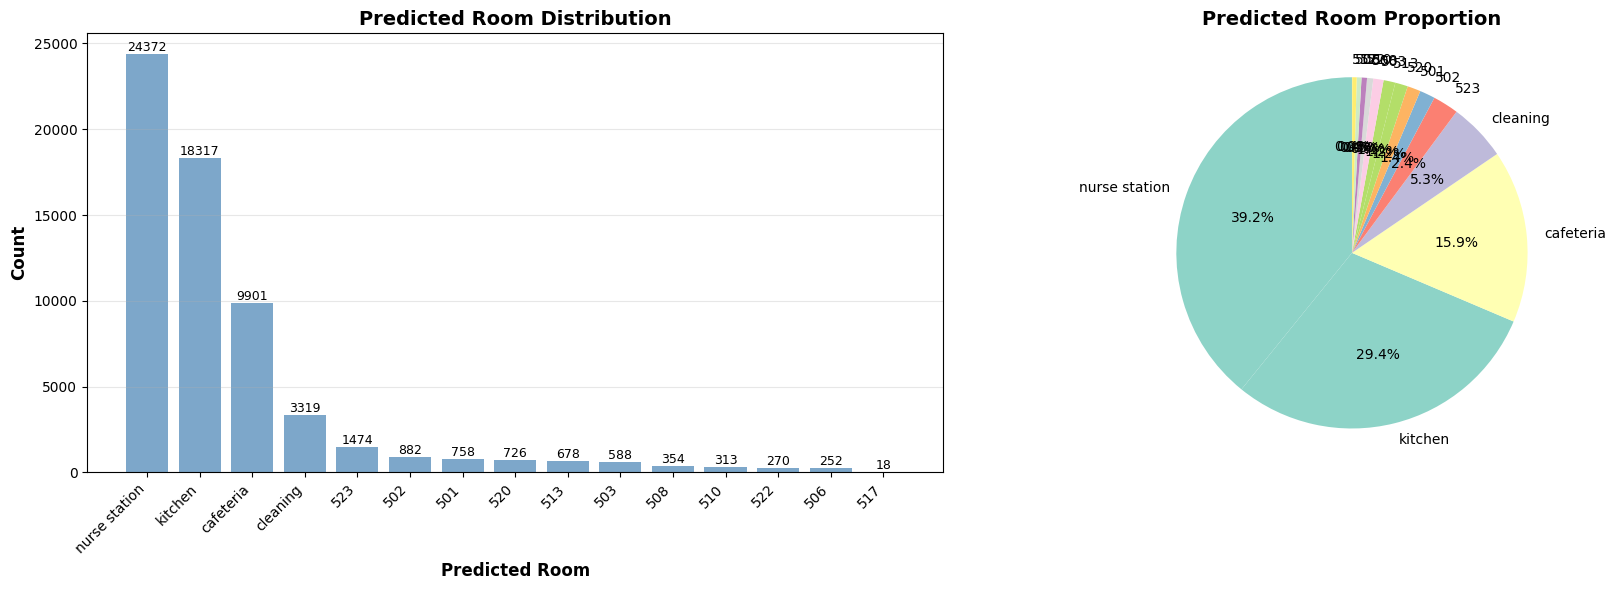

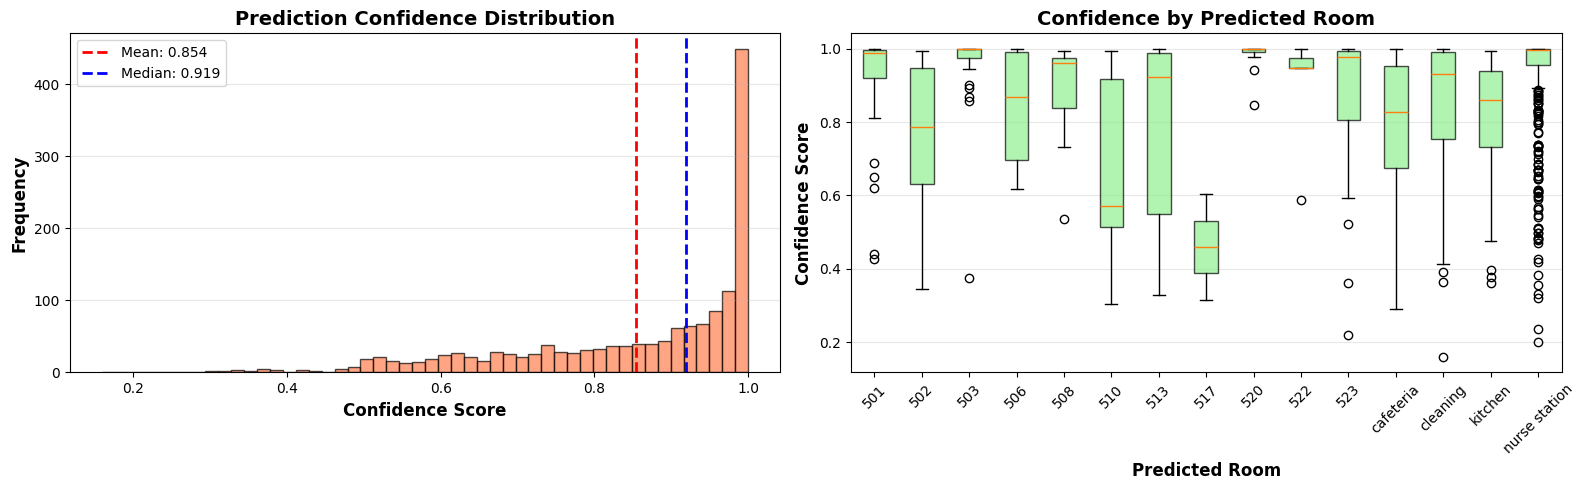


📊 Time Series Analysis (First 500 windows)...


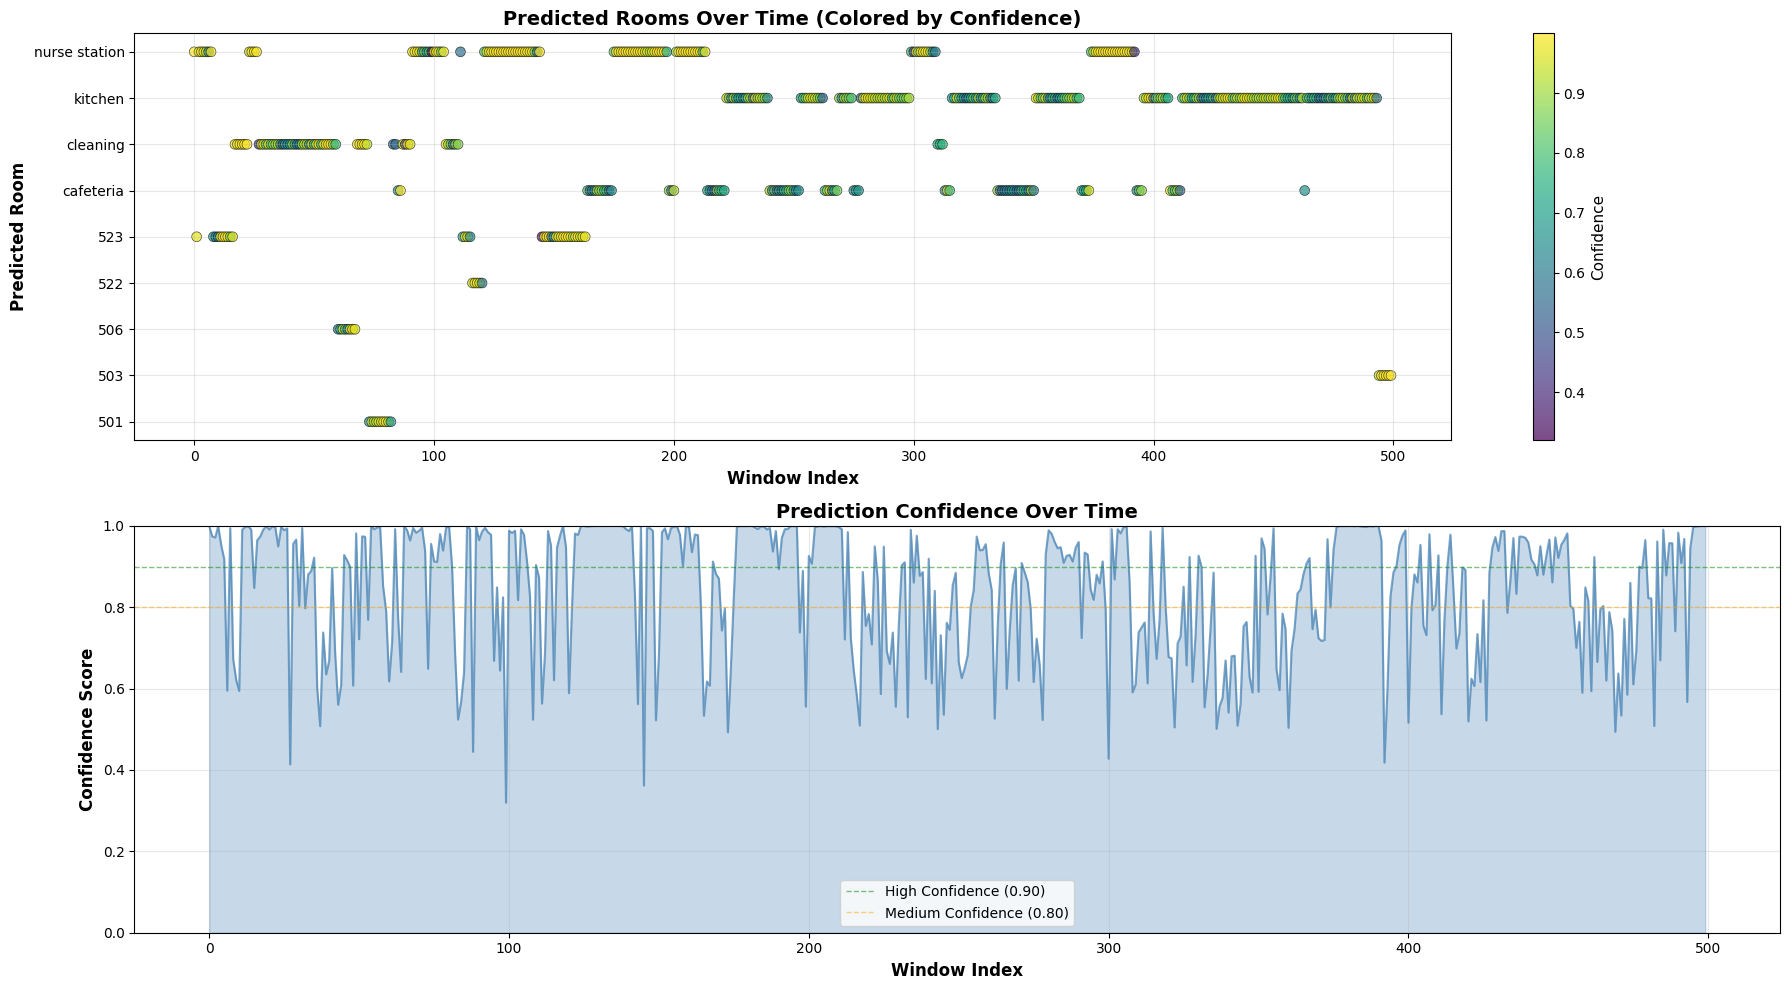


────────────────────────────────────────────────────────────────────────────
PER-ROOM STATISTICS
────────────────────────────────────────────────────────────────────────────

         Room  Count Percentage Avg Confidence Min Confidence Max Confidence
          501     34      2.23%         0.9110         0.4256         0.9997
          502     11      0.72%         0.7647         0.3438         0.9932
          503     27      1.77%         0.9545         0.3745         0.9999
          506      8      0.52%         0.8364         0.6177         0.9999
          508      7      0.46%         0.8736         0.5350         0.9928
          510      8      0.52%         0.6662         0.3026         0.9944
          513     14      0.92%         0.7725         0.3286         0.9995
          517      2      0.13%         0.4596         0.3157         0.6034
          520     17      1.11%         0.9843         0.8469         1.0000
          522      5      0.33%         0.8917        

In [18]:
# =============================================================================
# 5. VISUALIZATION & ANALYSIS
# =============================================================================

print(f"\n{'='*80}")
print("PREDICTION ANALYSIS & VISUALIZATION")
print(f"{'='*80}")

# ===== 1. Predicted Room Distribution =====
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
pred_counts_sorted = pred_counts.sort_values(ascending=False)
axes[0].bar(range(len(pred_counts_sorted)), pred_counts_sorted.values, color='steelblue', alpha=0.7)
axes[0].set_xticks(range(len(pred_counts_sorted)))
axes[0].set_xticklabels(pred_counts_sorted.index, rotation=45, ha='right')
axes[0].set_xlabel('Predicted Room', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Predicted Room Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (room, count) in enumerate(pred_counts_sorted.items()):
    axes[0].text(i, count, str(count), ha='center', va='bottom', fontsize=9)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(pred_counts)))
axes[1].pie(pred_counts.values, labels=pred_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Predicted Room Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ===== 2. Confidence Distribution =====
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(max_confidences, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0].axvline(max_confidences.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {max_confidences.mean():.3f}')
axes[0].axvline(np.median(max_confidences), color='blue', linestyle='--', linewidth=2, label=f'Median: {np.median(max_confidences):.3f}')
axes[0].set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot per room
room_confidences = []
room_labels = []
for room in sorted(results_df['predicted_room'].unique()):
    room_conf = results_df[results_df['predicted_room'] == room]['confidence'].values
    room_confidences.append(room_conf)
    room_labels.append(room)

bp = axes[1].boxplot(room_confidences, labels=room_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)
axes[1].set_xlabel('Predicted Room', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Confidence Score', fontsize=12, fontweight='bold')
axes[1].set_title('Confidence by Predicted Room', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ===== 3. Time Series Visualization (Sample) =====
print(f"\n📊 Time Series Analysis (First 500 windows)...")

sample_results = results_df.head(500).copy()
sample_results['time_idx'] = range(len(sample_results))

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Predicted rooms over time
unique_rooms = sorted(sample_results['predicted_room'].unique())
room_to_num = {room: i for i, room in enumerate(unique_rooms)}
sample_results['room_num'] = sample_results['predicted_room'].map(room_to_num)

axes[0].scatter(sample_results['time_idx'], sample_results['room_num'], 
                c=sample_results['confidence'], cmap='viridis', 
                s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0].set_yticks(range(len(unique_rooms)))
axes[0].set_yticklabels(unique_rooms)
axes[0].set_xlabel('Window Index', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Room', fontsize=12, fontweight='bold')
axes[0].set_title('Predicted Rooms Over Time (Colored by Confidence)', fontsize=14, fontweight='bold')
axes[0].grid(axis='both', alpha=0.3)
cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar.set_label('Confidence', fontsize=11)

# Confidence over time
axes[1].plot(sample_results['time_idx'], sample_results['confidence'], 
             color='steelblue', linewidth=1.5, alpha=0.7)
axes[1].axhline(0.90, color='green', linestyle='--', linewidth=1, label='High Confidence (0.90)', alpha=0.5)
axes[1].axhline(0.80, color='orange', linestyle='--', linewidth=1, label='Medium Confidence (0.80)', alpha=0.5)
axes[1].fill_between(sample_results['time_idx'], sample_results['confidence'], 
                      alpha=0.3, color='steelblue')
axes[1].set_xlabel('Window Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Confidence Score', fontsize=12, fontweight='bold')
axes[1].set_title('Prediction Confidence Over Time', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='both', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# ===== 4. Summary Statistics Table =====
print(f"\n{'─'*76}")
print("PER-ROOM STATISTICS")
print(f"{'─'*76}")

room_stats = []
for room in sorted(results_df['predicted_room'].unique()):
    room_data = results_df[results_df['predicted_room'] == room]
    room_stats.append({
        'Room': room,
        'Count': len(room_data),
        'Percentage': f"{len(room_data) / len(results_df) * 100:.2f}%",
        'Avg Confidence': f"{room_data['confidence'].mean():.4f}",
        'Min Confidence': f"{room_data['confidence'].min():.4f}",
        'Max Confidence': f"{room_data['confidence'].max():.4f}"
    })

room_stats_df = pd.DataFrame(room_stats)
print(f"\n{room_stats_df.to_string(index=False)}")

print(f"\n{'='*80}")
print(f"✅ VISUALIZATION COMPLETED!")
print(f"{'='*80}")